In [77]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [81]:
# Load cleaned CSV
df = pd.read_csv('../data/cleaned/cleaned_movies.csv')

# Quick check
print(df.shape)
print(df.head())
print(df.isna().sum())

(1000, 15)
                                         Poster_Link  \
0  https://m.media-amazon.com/images/M/MV5BMDFkYT...   
1  https://m.media-amazon.com/images/M/MV5BM2MyNj...   
2  https://m.media-amazon.com/images/M/MV5BMTMxNT...   
3  https://m.media-amazon.com/images/M/MV5BMWMwMG...   
4  https://m.media-amazon.com/images/M/MV5BMWU4N2...   

               Series_Title  Released_Year Certificate  Runtime  IMDB_Rating  \
0  The Shawshank Redemption         1994.0           A  142 min          9.3   
1             The Godfather         1972.0           A  175 min          9.2   
2           The Dark Knight         2008.0          UA  152 min          9.0   
3    The Godfather: Part II         1974.0           A  202 min          9.0   
4              12 Angry Men         1957.0           U   96 min          9.0   

                                            Overview  Meta_score  \
0  Two imprisoned men bond over a number of years...        80.0   
1  An organized crime dynasty's agi

In [83]:
# Target
y = df['Gross']

# Features
X = df[['Runtime', 'IMDB_Rating', 'Meta_score', 'No_of_Votes', 'Released_Year']].copy()

# Check initial stats
print(X.head())
print(X.isna().sum())

   Runtime  IMDB_Rating  Meta_score  No_of_Votes  Released_Year
0  142 min          9.3        80.0      2343110         1994.0
1  175 min          9.2       100.0      1620367         1972.0
2  152 min          9.0        84.0      2303232         2008.0
3  202 min          9.0        90.0      1129952         1974.0
4   96 min          9.0        96.0       689845         1957.0
Runtime            0
IMDB_Rating        0
Meta_score       157
No_of_Votes        0
Released_Year      0
dtype: int64


In [84]:
# Extract digits from Runtime and convert to float
X['Runtime'] = pd.to_numeric(X['Runtime'].str.extract(r'(\d+)')[0], errors='coerce')

# Fill missing numeric values with median
X = X.fillna(X.median())

# Check if all NaNs are handled
print(X.isna().sum())  # Should all be 0

Runtime          0
IMDB_Rating      0
Meta_score       0
No_of_Votes      0
Released_Year    0
dtype: int64


In [85]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)  

(800, 5) (200, 5)


In [88]:
# Drop rows where Gross is NaN
df_model = df.dropna(subset=['Gross']).copy()

# Target
y = df_model['Gross']

# Features
X = df_model[['Runtime', 'IMDB_Rating', 'Meta_score', 'No_of_Votes', 'Released_Year']].copy()

In [89]:
# Convert Runtime from '142 min' to float
X['Runtime'] = pd.to_numeric(X['Runtime'].str.extract(r'(\d+)')[0], errors='coerce')

# Fill missing numeric features with median
X = X.fillna(X.median())

In [90]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)  
print(y_train.isna().sum())  

(664, 5) (167, 5)
0


In [91]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [92]:
# Predictions
y_pred = model.predict(X_test)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2}")

Mean Squared Error: 7024453867744676.0
R^2 Score: 0.5043705099331302


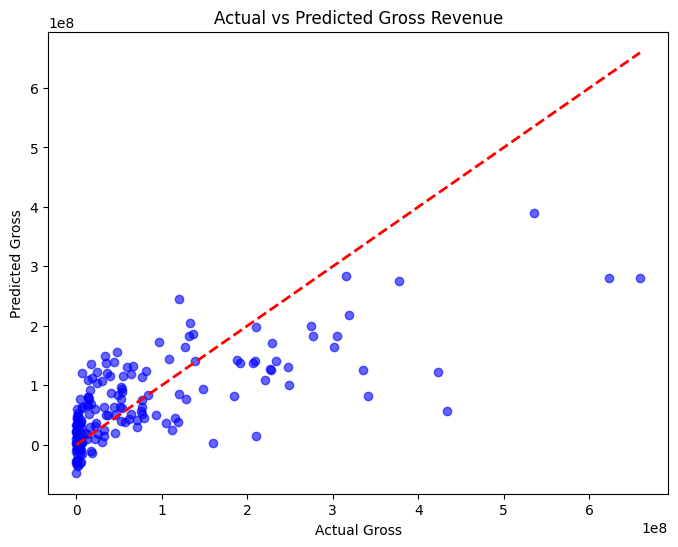

In [94]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)  # perfect prediction line
plt.xlabel('Actual Gross')
plt.ylabel('Predicted Gross')
plt.title('Actual vs Predicted Gross Revenue')
plt.show()